# 量化部署实验室：ONNX、INT8、性能与服务验收

这是第 25～30 课的贯通专题。我们使用仓库中真实的 FP32/INT8 ONNX 文件和 FastAPI/WebSocket 服务，不用伪造 benchmark 数字。

完成后你应该能够：

1. 把 PyTorch、ONNX FP32、ONNX INT8 放在同一组固定输入上比较；
2. 分开验证 logits 与 streaming cache，而不是只看模型能否加载；
3. 解释动态量化、静态 PTQ、QAT、QDQ/QOperator 的边界；
4. 正确做 warm-up、固定线程、重复测量、P50/P95/P99 与 RTF；
5. 理解 INT8 不保证更小、更快，也不保证 CER/WER 不变；
6. 验证 HTTP shape 契约、WebSocket 会话状态和错误响应；
7. 写出上线前的质量—延迟—内存—容量验收表。

仓库模型是确定性随机权重，只能验证部署机制，不能报告识别准确率。


## 0. 部署不是“导出成功”

```text
训练模型
  → 固定输入/输出/cache契约
  → ONNX导出与图检查
  → 原框架/运行时数值一致性
  → FP32基准
  → 量化与误差分析
  → INT8质量/性能基准
  → HTTP/WebSocket协议
  → 并发、尾延迟、故障与资源回收
  → 灰度、监控、回滚
```

任一阶段失败，都不能用“文件已经生成”代替验收。


In [1]:
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import torch
from fastapi.testclient import TestClient
from IPython.display import clear_output, display

def find_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("请从 learn_asr 或 notebooks 目录启动 Jupyter")

ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from deployment.model import (
    CACHE_FRAMES, CHUNK_FRAMES, FEATURE_DIM, NUM_CLASSES, build_model
)

FP32_PATH = ROOT / "artifacts" / "streaming_ctc_demo.onnx"
INT8_PATH = ROOT / "artifacts" / "streaming_ctc_demo.int8.onnx"
assert FP32_PATH.exists() and INT8_PATH.exists()

def sha256(path):
    digest = hashlib.sha256()
    digest.update(Path(path).read_bytes())
    return digest.hexdigest()

print("Python:", platform.python_version(), "｜PyTorch:", torch.__version__, "｜ORT:", ort.__version__)
print("系统：", platform.platform())


Python: 3.13.12 ｜PyTorch: 2.13.0+cpu ｜ORT: 1.28.0
系统： Windows-11-10.0.26200-SP0


<REPO_ROOT>\.venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 1. 先审计模型契约和图

本模型每次输入 8 帧、每帧 24 维，并显式输入/输出 2 帧 cache：

- `frames [1,8,24] float32`
- `cache [1,2,24] float32`
- `logits [1,8,11] float32`
- `new_cache [1,2,24] float32`

这些 shape、dtype、名称、opset、模型哈希和词表版本都应成为发布契约。


In [2]:
def tensor_shape(value_info):
    return [dimension.dim_value or dimension.dim_param for dimension in value_info.type.tensor_type.shape.dim]

def inspect_onnx(path):
    model = onnx.load(path)
    onnx.checker.check_model(model)
    return {
        "file": path.name,
        "bytes": path.stat().st_size,
        "sha256": sha256(path),
        "ir_version": model.ir_version,
        "opsets": [(item.domain, item.version) for item in model.opset_import],
        "inputs": [(item.name, tensor_shape(item), item.type.tensor_type.elem_type) for item in model.graph.input],
        "outputs": [(item.name, tensor_shape(item), item.type.tensor_type.elem_type) for item in model.graph.output],
        "ops": sorted({node.op_type for node in model.graph.node}),
        "nodes": len(model.graph.node),
    }

fp32_info = inspect_onnx(FP32_PATH)
int8_info = inspect_onnx(INT8_PATH)
for info in [fp32_info, int8_info]:
    print(json.dumps(info, ensure_ascii=False, indent=2))

assert fp32_info["inputs"] == int8_info["inputs"]
assert fp32_info["outputs"] == int8_info["outputs"]


{
  "file": "streaming_ctc_demo.onnx",
  "bytes": 8157,
  "sha256": "3e345ab9b540d19ccc6ca582766b6f714058dc0363fab26ca139c7372a7c14c4",
  "ir_version": 10,
  "opsets": [
    [
      "",
      18
    ]
  ],
  "inputs": [
    [
      "frames",
      [
        1,
        8,
        24
      ],
      1
    ],
    [
      "cache",
      [
        1,
        2,
        24
      ],
      1
    ]
  ],
  "outputs": [
    [
      "logits",
      [
        1,
        8,
        11
      ],
      1
    ],
    [
      "new_cache",
      [
        1,
        2,
        24
      ],
      1
    ]
  ],
  "ops": [
    "Add",
    "Concat",
    "Conv",
    "MatMul",
    "Relu",
    "Slice",
    "Transpose"
  ],
  "nodes": 8
}
{
  "file": "streaming_ctc_demo.int8.onnx",
  "bytes": 10592,
  "sha256": "b390b32a0a6accb5933436f00e231037d841992d140900892863c6ef85bb90ac",
  "ir_version": 10,
  "opsets": [
    [
      "",
      18
    ]
  ],
  "inputs": [
    [
      "frames",
      [
        1,
        8,
      

<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

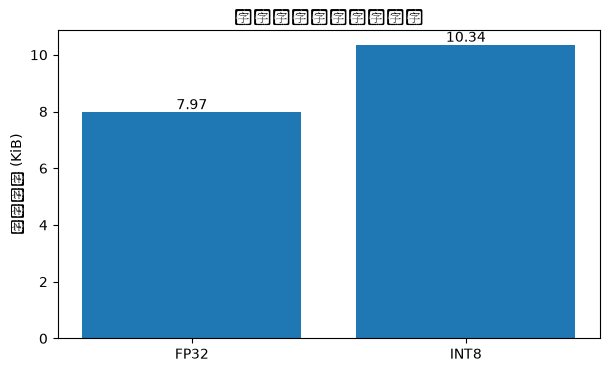

INT8/FP32 文件大小比：1.299
这个模型极小，量化算子与 scale/zero-point 元数据开销超过权重节省；大模型结论可能不同，仍需实测。


In [3]:
sizes_kib = np.array([fp32_info["bytes"], int8_info["bytes"]]) / 1024
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["FP32", "INT8"], sizes_kib)
ax.set(ylabel="文件大小 (KiB)", title="量化后文件不一定更小")
for bar, value in zip(bars, sizes_kib):
    ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.2f}", ha="center", va="bottom")
plt.show()

ratio = int8_info["bytes"] / fp32_info["bytes"]
print(f"INT8/FP32 文件大小比：{ratio:.3f}")
print("这个模型极小，量化算子与 scale/zero-point 元数据开销超过权重节省；大模型结论可能不同，仍需实测。")


## 2. 三个执行后端使用完全相同的输入

公平比较必须固定：随机种子、输入数组、模型权重、预处理、cache 初值、线程数和 provider。若每个后端重新随机生成输入，误差数字没有意义。


In [4]:
def make_session(path, threads=1):
    options = ort.SessionOptions()
    options.intra_op_num_threads = threads
    options.inter_op_num_threads = 1
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(str(path), sess_options=options, providers=["CPUExecutionProvider"])

torch_model = build_model()
fp32_session = make_session(FP32_PATH)
int8_session = make_session(INT8_PATH)

rng = np.random.default_rng(2026)
frames = rng.normal(size=(1, CHUNK_FRAMES, FEATURE_DIM)).astype(np.float32)
cache = rng.normal(size=(1, CACHE_FRAMES, FEATURE_DIM)).astype(np.float32)

with torch.inference_mode():
    torch_outputs = torch_model(torch.from_numpy(frames), torch.from_numpy(cache))
torch_outputs = tuple(output.numpy() for output in torch_outputs)
fp32_outputs = tuple(fp32_session.run(None, {"frames": frames, "cache": cache}))
int8_outputs = tuple(int8_session.run(None, {"frames": frames, "cache": cache}))

for name, outputs in [("Torch", torch_outputs), ("ONNX FP32", fp32_outputs), ("ONNX INT8", int8_outputs)]:
    print(name, [item.shape for item in outputs], [item.dtype for item in outputs])


Torch [(1, 8, 11), (1, 2, 24)] [dtype('float32'), dtype('float32')]
ONNX FP32 [(1, 8, 11), (1, 2, 24)] [dtype('float32'), dtype('float32')]
ONNX INT8 [(1, 8, 11), (1, 2, 24)] [dtype('float32'), dtype('float32')]


In [5]:
def error_summary(reference, actual):
    difference = np.asarray(actual, dtype=np.float64) - np.asarray(reference, dtype=np.float64)
    absolute = np.abs(difference).reshape(-1)
    denominator = np.maximum(np.abs(np.asarray(reference, dtype=np.float64)).reshape(-1), 1e-6)
    relative = absolute / denominator
    return {
        "max_abs": float(absolute.max(initial=0)),
        "mean_abs": float(absolute.mean()),
        "p99_abs": float(np.percentile(absolute, 99)),
        "max_rel_guarded": float(relative.max(initial=0)),
    }

comparisons = {
    "Torch→FP32 logits": error_summary(torch_outputs[0], fp32_outputs[0]),
    "Torch→FP32 cache": error_summary(torch_outputs[1], fp32_outputs[1]),
    "FP32→INT8 logits": error_summary(fp32_outputs[0], int8_outputs[0]),
    "FP32→INT8 cache": error_summary(fp32_outputs[1], int8_outputs[1]),
}
for name, summary in comparisons.items():
    print(name, summary)

assert comparisons["Torch→FP32 logits"]["max_abs"] < 1e-5
assert comparisons["Torch→FP32 cache"]["max_abs"] < 1e-7


Torch→FP32 logits {'max_abs': 1.1920928955078125e-07, 'mean_abs': 3.4797598015178337e-08, 'p99_abs': 1.1920928955078125e-07, 'max_rel_guarded': 2.460701822918669e-06}
Torch→FP32 cache {'max_abs': 0.0, 'mean_abs': 0.0, 'p99_abs': 0.0, 'max_rel_guarded': 0.0}
FP32→INT8 logits {'max_abs': 0.006911814212799072, 'mean_abs': 0.0019099891439757564, 'p99_abs': 0.00643007159233093, 'max_rel_guarded': 0.2942338450602179}
FP32→INT8 cache {'max_abs': 0.0, 'mean_abs': 0.0, 'p99_abs': 0.0, 'max_rel_guarded': 0.0}


### 相对误差为什么可能看起来很大

参考值接近 0 时，很小的绝对误差也会产生巨大相对误差。因此部署验收通常同时看 max/mean/P99 absolute error、带保护分母的 relative error、余弦相似度、argmax/top-k 一致率，以及最终 CER/WER。

数值接近只是必要条件。分类边界附近的微小变化仍可能改变 token 和文本。


## 3. 多样本与流式 cache 漂移

只测一个随机输入太弱。下面连续运行多个 chunk，让每个后端把自己的 `new_cache` 传给下一步，观察量化误差是否随状态递推积累。


<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35813 (\N{CJK UNIFIED IDEOGRAPH-8BE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36328 (\N{CJK UNIFIED IDEOGRAPH-8DE8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

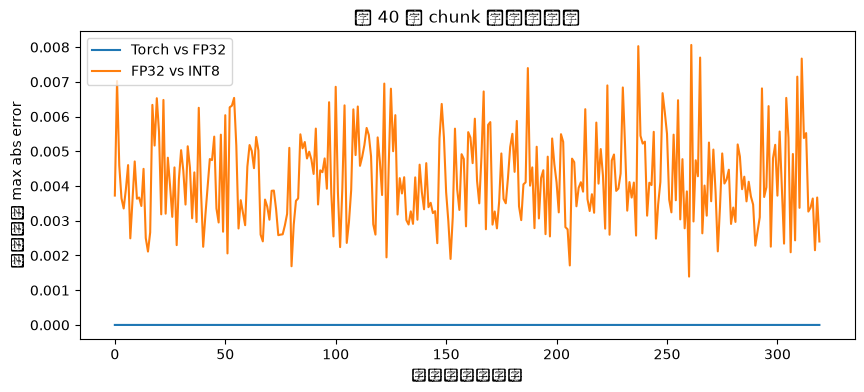

Torch/FP32 stream max error： 2.384185791015625e-07
FP32/INT8 stream max error： 0.008062481880187988
FP32/INT8 frame argmax agreement： 0.99375
最终 cache FP32/INT8 max error： 0.0


In [6]:
def run_ort_stream(session, chunks):
    state = np.zeros((1, CACHE_FRAMES, FEATURE_DIM), np.float32)
    logits = []
    caches = []
    for chunk in chunks:
        output, state = session.run(None, {"frames": chunk, "cache": state})
        logits.append(output)
        caches.append(state.copy())
    return np.concatenate(logits, axis=1), caches

def run_torch_stream(model, chunks):
    state = torch.zeros(1, CACHE_FRAMES, FEATURE_DIM)
    logits = []
    caches = []
    with torch.inference_mode():
        for chunk in chunks:
            output, state = model(torch.from_numpy(chunk), state)
            logits.append(output.numpy())
            caches.append(state.numpy().copy())
    return np.concatenate(logits, axis=1), caches

rng = np.random.default_rng(77)
chunks = [rng.normal(size=(1, CHUNK_FRAMES, FEATURE_DIM)).astype(np.float32) for _ in range(40)]
torch_stream, torch_caches = run_torch_stream(torch_model, chunks)
fp32_stream, fp32_caches = run_ort_stream(fp32_session, chunks)
int8_stream, int8_caches = run_ort_stream(int8_session, chunks)

fp32_error = np.max(np.abs(torch_stream - fp32_stream), axis=(0, 2))
int8_error = np.max(np.abs(fp32_stream - int8_stream), axis=(0, 2))
agreement = (fp32_stream.argmax(-1) == int8_stream.argmax(-1)).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fp32_error, label="Torch vs FP32")
ax.plot(int8_error, label="FP32 vs INT8")
ax.set(xlabel="累计流式时间步", ylabel="该时间步 max abs error", title="跨 40 个 chunk 的输出误差")
ax.legend()
plt.show()

print("Torch/FP32 stream max error：", float(fp32_error.max()))
print("FP32/INT8 stream max error：", float(int8_error.max()))
print("FP32/INT8 frame argmax agreement：", float(agreement))
print("最终 cache FP32/INT8 max error：", float(np.max(np.abs(fp32_caches[-1] - int8_caches[-1]))))


## 4. INT8 路线不是只有一种

- **动态量化**：权重预量化，部分激活运行时动态计算尺度；上手快，效果依算子和硬件而异。
- **静态 PTQ**：权重和激活使用校准数据确定范围；校准集必须代表真实设备、噪声、长度与说话方式。
- **QAT**：训练时模拟量化误差，可能恢复精度，但训练流程更复杂。
- **QOperator/QLinear** 与 **QDQ**：ONNX 图中表示量化的不同风格，执行 provider 支持情况不同。

当前 INT8 图包含 `DynamicQuantizeLinear`、`ConvInteger` 和 `MatMulInteger`，属于动态整数量化教学产物。不能把它的结论直接推广到 GPU、NPU 或静态校准模型。


## 5. Benchmark：先固定方法，再看数字

本实验固定 CPU provider 和单线程，先 warm-up，再记录每次调用延迟。小模型经常被 Python/ORT 调用开销主导，INT8 可能反而慢；大型矩阵和适合的硬件才更可能体现整数吞吐优势。


FP32：

 {'mean_ms': 0.01698925, 'p50_ms': 0.0165, 'p95_ms': 0.0175, 'p99_ms': 0.0219, 'throughput_chunks_s': 58860.75018026104, 'model_only_rtf': 0.000212365625}
INT8： {'mean_ms': 0.030183, 'p50_ms': 0.0266, 'p95_ms': 0.04950999999999999, 'p99_ms': 0.058404, 'throughput_chunks_s': 33131.232813172974, 'model_only_rtf': 0.00037728750000000003}
INT8/FP32 mean latency ratio： 1.7765940226908192


<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24310 (\N{CJK UNIFIED IDEOGRAPH-5EF6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36831 (\N{CJK UNIFIED IDEOGRAPH-8FDF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
<REPO_ROOT>\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22266 (\N{CJK UNIFIED IDEOGRAPH-56FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

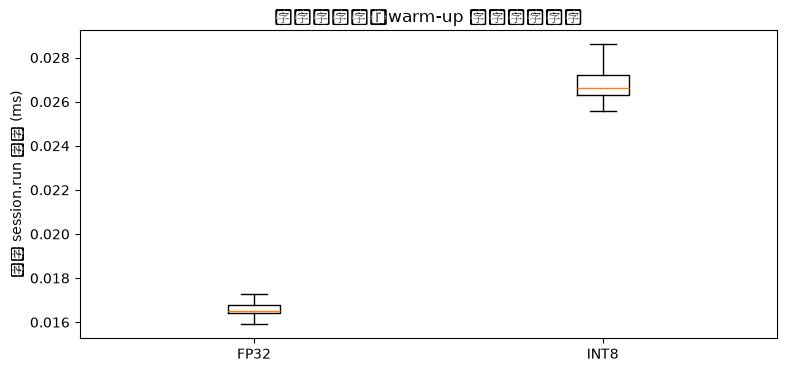

In [7]:
def benchmark_session(session, frames, cache, warmup=50, repeats=400):
    feeds = {"frames": frames, "cache": cache}
    for _ in range(warmup):
        session.run(None, feeds)
    durations_ms = np.empty(repeats, dtype=np.float64)
    for index in range(repeats):
        start = time.perf_counter_ns()
        session.run(None, feeds)
        durations_ms[index] = (time.perf_counter_ns() - start) / 1e6
    return durations_ms

fp32_latency = benchmark_session(fp32_session, frames, cache)
int8_latency = benchmark_session(int8_session, frames, cache)

def latency_report(values, chunk_audio_ms=CHUNK_FRAMES * 10):
    p50, p95, p99 = np.percentile(values, [50, 95, 99])
    return {
        "mean_ms": float(values.mean()),
        "p50_ms": float(p50),
        "p95_ms": float(p95),
        "p99_ms": float(p99),
        "throughput_chunks_s": float(1000 / values.mean()),
        "model_only_rtf": float(values.mean() / chunk_audio_ms),
    }

fp32_benchmark = latency_report(fp32_latency)
int8_benchmark = latency_report(int8_latency)
print("FP32：", fp32_benchmark)
print("INT8：", int8_benchmark)
print("INT8/FP32 mean latency ratio：", int8_benchmark["mean_ms"] / fp32_benchmark["mean_ms"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([fp32_latency, int8_latency], tick_labels=["FP32", "INT8"], showfliers=False)
ax.set(ylabel="单次 session.run 延迟 (ms)", title="固定单线程、warm-up 后的本机分布")
plt.show()


### 这份 benchmark 没有测什么

- 没有测 Log-Mel、解码、序列化和网络；
- 没有测真实模型或真实 CER/WER；
- 没有测多 batch、动态长度、GPU/NPU；
- 没有测进程启动、模型加载和冷缓存；
- 没有测持续并发时的排队与内存。

所以这里的 RTF 是 model-only RTF，不能当作端到端服务 RTF。


## 6. 并发：共享只读 session，隔离每会话 cache

ONNX Runtime session 可被多个请求调用，但 streaming cache 属于具体会话。服务可以共享模型权重和 session，不能共享可变 cache、decoder beam、pending frames 或 transcript。


In [8]:
def run_one(feed_seed):
    local_rng = np.random.default_rng(feed_seed)
    local_frames = local_rng.normal(size=(1, CHUNK_FRAMES, FEATURE_DIM)).astype(np.float32)
    local_cache = local_rng.normal(size=(1, CACHE_FRAMES, FEATURE_DIM)).astype(np.float32)
    return int8_session.run(None, {"frames": local_frames, "cache": local_cache})

seeds = list(range(32))
serial = [run_one(seed) for seed in seeds]
with ThreadPoolExecutor(max_workers=4) as pool:
    concurrent = list(pool.map(run_one, seeds))
for expected, actual in zip(serial, concurrent):
    assert np.array_equal(expected[0], actual[0])
    assert np.array_equal(expected[1], actual[1])
print("4线程交错调用同一只读 ORT session：32 组输出完全一致")

stream_a = chunks[:5]
stream_b = [(-chunk).copy() for chunk in chunks[:5]]
separate_a = run_ort_stream(int8_session, stream_a)[0]
separate_b = run_ort_stream(int8_session, stream_b)[0]
caches = {
    "A": np.zeros((1, CACHE_FRAMES, FEATURE_DIM), np.float32),
    "B": np.zeros((1, CACHE_FRAMES, FEATURE_DIM), np.float32),
}
interleaved = {"A": [], "B": []}
for index in range(5):
    for session_id, stream in [("A", stream_a), ("B", stream_b)]:
        output, caches[session_id] = int8_session.run(None, {"frames": stream[index], "cache": caches[session_id]})
        interleaved[session_id].append(output)
assert np.array_equal(np.concatenate(interleaved["A"], axis=1), separate_a)
assert np.array_equal(np.concatenate(interleaved["B"], axis=1), separate_b)
print("A/B 会话交错运行，与分别运行完全一致")


4线程交错调用同一只读 ORT session：32 组输出完全一致
A/B 会话交错运行，与分别运行完全一致


## 7. HTTP 契约：错误输入也必须可预测

教学服务 `/infer` 接受恰好 `[8,24]` 的 frames 和可选 `[2,24]` cache。合法输入返回 logits/cache；shape 错误返回 422，而不是泄漏内部堆栈或变成不明确的 500。


In [9]:
from deployment.app import app

client = TestClient(app, raise_server_exceptions=False)
health = client.get("/health")
assert health.status_code == 200
print("GET /health：", health.json())

valid_payload = {
    "frames": np.zeros((CHUNK_FRAMES, FEATURE_DIM), np.float32).tolist(),
    "cache": np.zeros((CACHE_FRAMES, FEATURE_DIM), np.float32).tolist(),
}
response = client.post("/infer", json=valid_payload)
assert response.status_code == 200
body = response.json()
assert np.asarray(body["logits"]).shape == (CHUNK_FRAMES, NUM_CLASSES)
assert np.asarray(body["cache"]).shape == (CACHE_FRAMES, FEATURE_DIM)
print("POST /infer valid：", response.status_code, "logits", np.asarray(body["logits"]).shape)

invalid_payload = {"frames": np.zeros((CHUNK_FRAMES - 1, FEATURE_DIM)).tolist()}
bad_response = client.post("/infer", json=invalid_payload)
assert bad_response.status_code == 422
print("POST /infer invalid：", bad_response.status_code, bad_response.json())


GET /health：

 {'status': 'ok', 'model': 'streaming_ctc_demo.int8.onnx', 'provider': 'CPUExecutionProvider'}
POST /infer valid： 200 logits (8, 11)
POST /infer invalid： 422 {'detail': 'frames shape must be (8, 24), got (7, 24)'}


## 8. WebSocket：状态属于连接

每条 WebSocket 连接持有自己的 cache、pending frames、CTC previous token、transcript 和 sequence number。下面同时打开 A/B 两条连接并交错发送，验证序号都从 1 开始、final 各自结束。


In [10]:
features_a = np.ones((CHUNK_FRAMES, FEATURE_DIM), np.float32).tolist()
features_b = (-np.ones((CHUNK_FRAMES, FEATURE_DIM), np.float32)).tolist()

with client.websocket_connect("/stream") as ws_a:
    with client.websocket_connect("/stream") as ws_b:
        ws_a.send_json({"features": features_a})
        ws_b.send_json({"features": features_b})
        result_a = ws_a.receive_json()
        result_b = ws_b.receive_json()
        assert result_a["sn"] == 1 and result_b["sn"] == 1
        assert result_a["ls"] is False and result_b["ls"] is False

        ws_a.send_json({"eof": True})
        final_a = ws_a.receive_json()
        ws_b.send_json({"eof": True})
        final_b = ws_b.receive_json()
        assert final_a["ls"] is True and final_b["ls"] is True
        assert final_a["sn"] == 2 and final_b["sn"] == 2

print("双 WebSocket 会话交错测试通过")
print("A partial/final：", result_a, final_a)
print("B partial/final：", result_b, final_b)


双 WebSocket 会话交错测试通过


A partial/final： {'sn': 1, 'pgs': 'apd', 'text': '8', 'full': '8', 'ls': False} {'sn': 2, 'pgs': 'apd', 'text': '', 'full': '8', 'ls': True}
B partial/final： {'sn': 1, 'pgs': 'apd', 'text': '350', 'full': '350', 'ls': False} {'sn': 2, 'pgs': 'apd', 'text': '', 'full': '350', 'ls': True}


## 9. 生产验收矩阵

| 维度 | 至少要测 |
|---|---|
| 正确性 | 原框架/运行时、离线/流式、cache、动态/固定 shape、长短输入 |
| 质量 | 总体 CER/WER、设备/噪声/说话人/长度分桶、关键实体 |
| 量化 | FP32/INT8 质量差、logits 误差、argmax/N-best 变化、校准覆盖 |
| 延迟 | warm/cold、P50/P95/P99、首字、final、排队、端到端 RTF |
| 容量 | 并发、吞吐、CPU、RSS、每会话状态、backpressure |
| 稳定性 | 断连、超时、坏包、长会话、模型异常、内存回收 |
| 可观测性 | model/vocab/graph/frontend 版本、trace id、阶段耗时、错误码 |
| 发布 | 灰度比例、质量/延迟阈值、自动回滚、旧版本兼容 |
| 安全隐私 | 鉴权、限流、输入上限、日志脱敏、音频保留策略 |

平均延迟和单一 WER 不能代表生产验收。


## 10. 最终闭卷测试（40 分）

每题 0～2 分，达到 **32/40** 且代码题实际运行，才算通过。

### 概念与判断

1. ONNX 文件能加载，为什么不等于导出正确？
2. 分别写出 frames、cache、logits、new_cache 的 shape 与所有者。
3. 动态量化、静态 PTQ、QAT 的区别是什么？
4. 为什么 INT8 可能比 FP32 文件更大？
5. 为什么 INT8 可能在某台 CPU 上更慢？
6. max absolute error 很小，为什么 CER 仍可能变化？
7. warm-up、线程数、provider 为什么必须记录？
8. model-only RTF 与端到端 RTF 有什么区别？

### 编程与排错

9. 对 100 个固定随机输入比较 Torch/FP32/INT8 的 max、mean、P99 误差。
10. 连续运行 100 个 chunk，画 cache 与 logits 误差随时间变化。
11. 统计 FP32/INT8 argmax、top-k 和最终文本一致率。
12. 分别固定 1、2、4 线程测 P50/P95/P99，解释结果。
13. 构造一个量化后 token 翻转的边界输入。
14. 写模型 manifest，包含 SHA256、opset、shape、词表和前端版本。
15. 让 HTTP 非法 shape 返回稳定 422，并测试错误正文。
16. 同时运行多个 WebSocket，验证 cache、sn、文本和 final 不串话。
17. 增加有界队列和 backpressure 指标，构造过载测试。
18. 设计灰度规则：质量或 P99 超过什么阈值自动回滚？

### 系统设计

19. 画从音频进入到 PGS 返回的全链路，标出每段耗时与状态所有者。
20. 用 5 分钟解释“量化成功不是部署完成”，必须包含质量、尾延迟、容量和回滚。


<details><summary>展开关键答案与评分锚点</summary>

1. 还需固定输入上的数值、shape、状态和语义一致性。
2. 本模型分别为 `[1,8,24]`、`[1,2,24]`、`[1,8,11]`、`[1,2,24]`；模型权重共享，cache 属于会话。
3. 动态量化运行时处理激活尺度；静态 PTQ 用代表性校准集；QAT 在训练时模拟量化。
4. 极小模型中量化节点和尺度元数据固定开销可能更大。
5. 算子支持、矩阵尺寸、转换开销、线程和硬件指令都会影响速度。
6. 边界 logits 的微小变化会改变 argmax、搜索路径和文本。
7. 它们直接影响冷启动、调度和并行性能，缺失时 benchmark 不可复现。
8. model-only 只测模型调用；端到端还包括前端、解码、排队、协议和网络。

代码题必须保存环境、随机种子、输入、分布统计和断言。只贴一个平均耗时最多得 1 分。

</details>


## 11. 离场票

- [ ] 我能验证 Torch、FP32 ONNX、INT8 ONNX 的数值与状态契约。
- [ ] 我不会预设 INT8 更小或更快，而会在目标硬件测量。
- [ ] 我能把 model-only RTF 与端到端延迟分开。
- [ ] 我能报告 P50/P95/P99、吞吐、并发和资源使用。
- [ ] HTTP 错误输入有稳定状态码，WebSocket 多会话状态隔离。
- [ ] 我能用真实独立测试集比较 FP32/INT8 CER/WER。
- [ ] 我能写出灰度、监控和回滚条件。

完成这些证据后，再学习音频前端和语义模块如何共同影响生产质量。
